In [1]:
%load_ext autoreload
%autoreload 2
from env import *
plt.rcParams['figure.figsize'] = [8, 8]

Action:  [ 0.7277112  -0.76493627  0.03475821]  Observation:  {'observation': array([0., 0., 0., 0., 0.]), 'achieved_goal': array([0., 0., 0.]), 'desired_goal': array([ 2.84063292, -8.3172007 , -2.12604949])}  Reward:  -1.0  Done:  False
Action:  [-0.7358638   0.43371937 -0.2078806 ]  Observation:  {'observation': array([0., 0., 0., 0., 0.]), 'achieved_goal': array([0., 0., 0.]), 'desired_goal': array([ 2.84063292, -8.3172007 , -2.12604949])}  Reward:  -1.0  Done:  False
Action:  [ 0.13084263 -0.6334403  -0.7103045 ]  Observation:  {'observation': array([0., 0., 0., 0., 0.]), 'achieved_goal': array([0., 0., 0.]), 'desired_goal': array([ 2.84063292, -8.3172007 , -2.12604949])}  Reward:  -1.0  Done:  False
Action:  [-0.02388744 -0.28877452  0.8808639 ]  Observation:  {'observation': array([0., 0., 0., 0., 0.]), 'achieved_goal': array([0., 0., 0.]), 'desired_goal': array([ 2.84063292, -8.3172007 , -2.12604949])}  Reward:  -1.0  Done:  False
Action:  [0.5306505  0.49732724 0.8074395 ]  Obs

/home/kushal/LG/SAC_LG/env.py:28: YAMLLoadWarning: calling yaml.load() without Loader=... is deprecated, as the default Loader is unsafe. Please read https://msg.pyyaml.org/load for full details.
  raw_yaml = yaml.load(f)


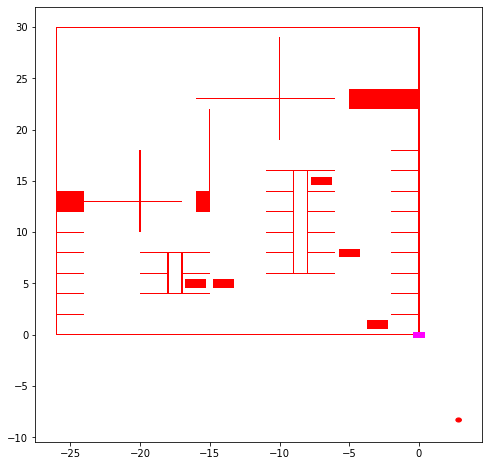

In [58]:
env_test = SecondOrderDiffDriveGoalEnv(yaml_file="/home/kushal/dirtmp/resources/input_files/environments/parking_lot_small.yaml")
for i in range(1):
    obs = env_test.reset(start = [0, 0.0, 0, 0, 0])
    traj = [np.copy(obs)]
    for step in range(10):
        action = env_test.action_space.sample()
        obs, reward, done, _ = env_test.step(action)
        traj.append(np.copy(obs))
        print("Action: ",action," Observation: ",obs," Reward: ",reward," Done: ",done)
        if done: break
    env_test._plot()
    plt.show()

In [59]:
class Tree():
    def __init__(self, folder = 'trees_random', num=0):
        with open(f'{folder}/edges/{num}.txt', 'r') as f:
            self.edges_raw_data = f.readlines()
        with open(f'{folder}/vertices/{num}.txt', 'r') as f:
            self.nodes_raw_data = f.readlines()
        
        self.solution_traj = []
        self.trajectory_list = []
        self.process_data()
        self.get_all_trajs(0, [])

    def process_data(self):
        self.nodes_map = {}
        max_node_num = -1
        for i in range(len(self.nodes_raw_data)//2):
            node_num = int(self.nodes_raw_data[2*i])
            node_val = list(map(float, self.nodes_raw_data[2*i+1].split(',')))
            self.nodes_map[node_num] = node_val
            max_node_num = max(max_node_num, node_num)

        self.edges_map = {i:[] for i in range(max_node_num+1)}
        for i in range(len(self.edges_raw_data)):
            src, tgt = list(map(int, self.edges_raw_data[i].split()))
            self.edges_map[src].append(tgt)

    def get_all_trajs(self, src, traj):
        if len(self.edges_map[src])==0:
            self.trajectory_list.append([self.nodes_map[x] for x in traj])
            return
        for tgt in self.edges_map[src]:
            traj_new = traj + [tgt]
            self.get_all_trajs(tgt, traj_new)

In [100]:
folder = f'/home/kushal/dirtmp/out/parkinglot/'
trees = []
for i in range(50):
    trees += [Tree(folder, num=i)]

In [101]:
def X(s):
    return int((s+13)/26.0*30)

def Y(s):
    return int((s-15)/30.0*30)

def get_trajectories_from_tree(tree):
    covered = np.zeros((31,31))
    trajectories = []
    for traj in tree.trajectory_list:
        t = traj[-1]
        if not covered[X(t[0]), Y(t[1])]:
            trajectories.append(traj)
            for t in traj: 
                covered[X(t[0]), Y(t[1])] = 1
    return trajectories
    
def get_trajectories_from_trees(trees, min_len = 10):
    trajectories = []
    for tree in trees:
        trajectories += get_trajectories_from_tree(tree)
    return trajectories
#     return [t for t in trajectories if len(t)>min_len]

In [102]:
train_trees = trees
train_trajectories = get_trajectories_from_trees(train_trees)

In [103]:
len(train_trajectories)

25850

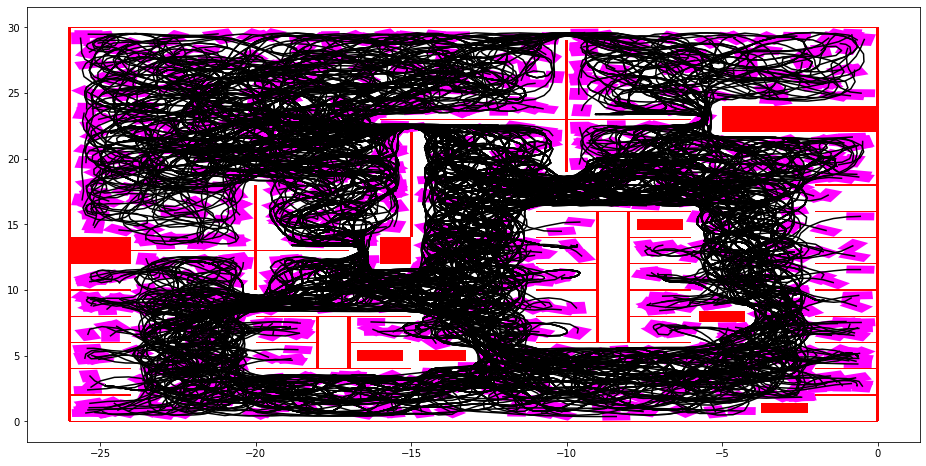

In [105]:
plt.rcParams['figure.figsize'] = [12, 12]
for t in random.sample(train_trajectories, 1000):
    env_test.env.plot_traj(t)

In [65]:
torchscript_path = './Theta_Deterministic.pt'
actor_model = torch.jit.load(torchscript_path)
actor_model.eval()

RecursiveScriptModule(
  original_name=Sequential
  (0): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Linear)
    (1): RecursiveScriptModule(original_name=ReLU)
    (2): RecursiveScriptModule(original_name=Linear)
    (3): RecursiveScriptModule(original_name=ReLU)
  )
  (1): RecursiveScriptModule(original_name=Linear)
  (2): RecursiveScriptModule(original_name=Tanh)
)

In [85]:
def _enforce_bounds(s):
    s_high = np.array([14,14,np.pi,0.7,0.7])
    s_low  = -s_high
    for i in range(5):
        if i<2: continue
        if i == 2:
            while s[i] > np.pi:
                s[i] -= 2*np.pi
            while s[i] < -np.pi:
                s[i] += 2*np.pi
        s[i] = np.clip(s[i],s_low[i],s_high[i])
    return s
    
def propagate_once(s,a):
    yicrL = -.3
    yicrR =  .3
    divisor = 1./(yicrL - yicrR)
    v_fwd =  (s[4]*yicrL-s[3]*yicrR)*divisor
    rot_z = (s[3] - s[4])*divisor

    dsdt = np.array([v_fwd*np.cos(s[2]),v_fwd*np.sin(s[2]),rot_z,a[0],a[1]])
    s += dsdt * 0.1
    s =  _enforce_bounds(s)
    return np.copy(s)
    
def reachable(s, goal):
    traj = []
    for k in range(100):
        current_state = list([0, 0, s[2], s[3], s[4]])
        desired_state = list(goal[:3])
        desired_state[0] -= s[0]
        desired_state[1] -= s[1]
        action = actor_model(torch.Tensor([current_state+desired_state]))[0].detach().cpu()
        for i in range(2):
            action[i] = np.clip(action[i],-1,1)
            action[i] = -0.2 + 0.4 * (action[i]+1)/2

        for i in range(10):
            s = propagate_once(np.copy(s), np.copy(action))
            if not env_test.env.valid_state(s): 
                return False, []
        traj.append(s)
        diff = _enforce_bounds(s-goal)[:3]
        if np.linalg.norm(diff) < 0.5: 
            return True, traj
    return False, []

def find_maximal_state(s, traj):
    lower, upper = 0, len(traj)-1
    idx = -1
    opt_traj = []
    
    flag, cand_traj = reachable(s, traj[-1])
    if flag: return len(traj)-1, cand_traj
    
    while lower <= upper:
        mid = int((lower + upper)/2)
        flag, cand_traj = reachable(s, traj[mid])
        if flag:
            opt_traj = cand_traj
            lower = mid+1
            idx = mid
        else:
            upper = mid-1
    return idx, opt_traj
    
def annotate_traj(traj):
    plt.subplot(1, 2, 1)
    env_test.env.plot_traj(traj)
#     plt.show()
    rewired_traj, state_num = [], 0

    start, lg, last_states = [], [], []
    
    local_goals = []
    while state_num < (len(traj)-1):
        max_idx, opt_traj = find_maximal_state(traj[state_num], traj[state_num+1:])
        if max_idx == -1: 
            max_idx = state_num + 1
            opt_traj = [traj[state_num]]
        else: 
            max_idx += state_num+1
            for s in opt_traj:
                start.append(s)
                lg.append(traj[max_idx])
                last_states.append(opt_traj[-1])
            traj[max_idx] = opt_traj[-1]
        state_num = max_idx
        rewired_traj += opt_traj 
        
        local_goals += [opt_traj[-1]]
    
    reachable_idx = None
    for idx in range(len(rewired_traj)):
        success, opt_traj = reachable(start[idx], rewired_traj[-1])
        if success:
            reachable_idx = idx
            break
            
    previous_lg = rewired_traj[-1]
    start, lg, last_states, rewired_traj = start[:reachable_idx], lg[:reachable_idx], \
                                        last_states[:reachable_idx], rewired_traj[:reachable_idx]

    for s in opt_traj:
        start.append(s)
        lg.append(previous_lg)
        last_states.append(opt_traj[-1])
    rewired_traj += opt_traj
    
    rewired_traj = [list(x) for x in rewired_traj]
    plt.subplot(1, 2, 2)
    env_test.env.plot_traj(rewired_traj)
    return rewired_traj, start, lg, last_states

0


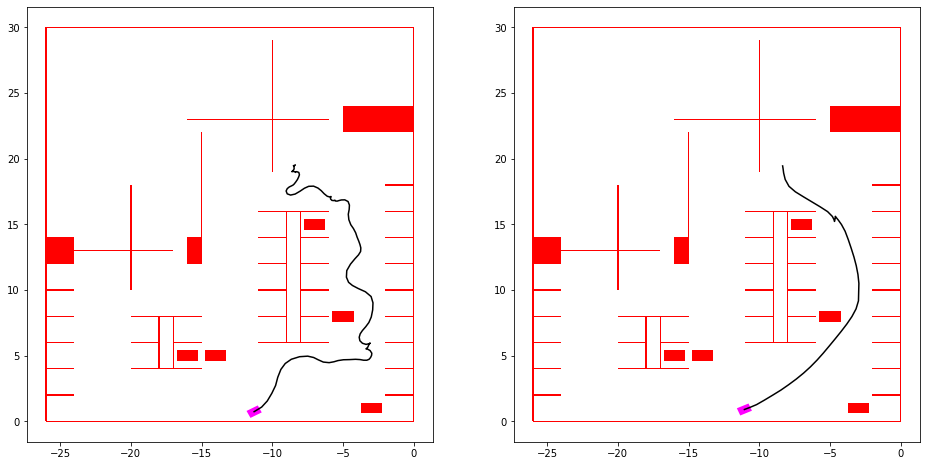

In [99]:
rewired_train = []
plt.rcParams['figure.figsize'] = [16, 8]
for idx, t in enumerate(random.sample(train_trajectories, 1)):
# for idx, t in enumerate(train_trajectories):
    if idx%100 == 0: print(idx)
    annot = annotate_traj(t)
#     try:
        
#     except: continue
    rewired_train += [annot]
    break

In [18]:
rewired_train = [annotate_traj(t) for t in train_trajectories]

In [12]:
import pickle

bugtap_traj = {'train': rewired_train}

filehandler = open("/home/kushal/dirtmp/out/parkinglot/trajs_annotated.pkl","wb")
pickle.dump(bugtap_traj,filehandler)
filehandler.close()